# Lecture: Data Visualization and Visual Thinking

This opening lecture introduces how we use visualizations to understand data. We will inspect a dataset, distinguish feature types, visualize quantitative and categorical distributions, evaluate whether a sample supports a claim, and examine how design choices can change a chart's message.


## Learning goals

By the end of this lecture, you should be able to:

- explain why visualizations efficiently summarize and communicate patterns;
- define a model as a mathematical representation of a pattern or relationship;
- recognize the basic parts of a Python notebook;
- explain why we import libraries such as Pandas and Matplotlib;
- distinguish observations from features;
- classify features as quantitative or categorical;
- use a histogram, bar chart, or pie chart to examine a distribution;
- distinguish claims about a dataset from claims about a population; and
- explain how labels, histogram bins, and axis limits affect interpretation.


## What are visualization and modeling for?

### Discussion

1. Why do we visualize data?
2. What is a model?


1. It's the quickest way to get data off the computer and into someone's brain.
2. A model is a mathematical representation of a relationship in data.

## A first look at Python

Python is a programming language. Compared with languages such as Java or C, Python usually requires less setup and fewer lines of code to express an idea. Its readable syntax and large collection of data-analysis libraries have made it one of the most important languages in data science.


## Why do we import libraries?

A **library** is a collection of code that other people have written and organized for us to use. Libraries let us focus on analyzing data instead of writing every operation from scratch.

Pandas is a Python library for working with table-shaped data. We import it using the alias `pd`, which is the convention used in most Python data-science examples.


In [3]:
import pandas as pd

The import cell makes Pandas available. It does not load our data yet.


## Read a data file

The `read_csv()` function reads a comma-separated values file and returns a Pandas **DataFrame**. A DataFrame is a table with rows and columns.


In [4]:
penguins_df = pd.read_csv("data/penguins.csv")

penguins_df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In this code:

- `penguins` is the name we gave the DataFrame;
- `pd.read_csv()` is the function that reads the file; and
- `.head()` asks the DataFrame to show its first few rows.


## Other file types use other reading functions

Data is not always stored in a CSV file. Pandas provides different reading functions for common file types. For example, `pd.read_json()` reads a JSON file, while `pd.read_excel()` reads an Excel workbook.

The small JSON file below contains the same kinds of penguin features. The result is still a DataFrame; only the reading function changes.


In [5]:
penguins_json_df = pd.read_json('data/penguins_sample.json')

penguins_json_df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181,3750,MALE
1,Adelie,Torgersen,39.5,17.4,186,3800,FEMALE
2,Adelie,Torgersen,40.3,18.0,195,3250,FEMALE


The general pattern is `pd.read_filetype("path/to/file")`. The file path tells Python where to find the data.


## Data dictionary

The Palmer Penguins data contains measurements of penguins observed in the Palmer Archipelago of Antarctica.

- `species`: the penguin species;
- `island`: the island where the observation was collected;
- `bill_length_mm`: bill length in millimeters;
- `bill_depth_mm`: bill depth in millimeters;
- `flipper_length_mm`: flipper length in millimeters;
- `body_mass_g`: body mass in grams; and
- `sex`: recorded sex, when available.

The dataset was made available through the `palmerpenguins` project using data from Palmer Station Antarctica LTER and researchers including Allison Horst, Alison Hill, and Kristen Gorman. The local files contain a fixed copy for this course.


## Observations and features

Each row is an **observation**. Each column is a **feature** describing an observation. Some features describe categories, while others record quantities that can be measured.

The `.head()` method displays the first five observations by default. The `.tail()` method displays the last five. Looking at both ends gives us a quick check of the table's structure without printing every row.


In [7]:
penguins_df.head(10)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,FEMALE
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,MALE
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN


In [8]:
penguins_df.tail()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE
343,Gentoo,Biscoe,49.9,16.1,213.0,5400.0,MALE


## Two common feature types

A **quantitative feature** records a numerical measurement or count for which arithmetic comparisons are meaningful.

A **categorical feature** records a label or group membership. Its values distinguish categories rather than amounts.

Use the data dictionary to decide which feature type best describes each column.


### Discussion: classify the features

Classify each feature as quantitative or categorical:

- `species` - categorical
- `island` - categorical
- `bill_length_mm` - quantitative
- `bill_depth_mm`- quantitative
- `flipper_length_mm` - quantitative
- `body_mass_g` - quantiative
- `sex` - categorical


## Data type versus feature type

A feature's meaning is different from the way Pandas stores its values.

- **Pandas data type:** How are the values stored?
- **Feature type:** What do the values represent, and how should we analyze them?

Common Pandas data types include `int64` for whole numbers, `float64` for numbers that may contain decimals or missing values, `object` or `string` for text, `bool` for `True` and `False`, and `datetime64` for dates and times.

Storage type and feature type often line up, but not always. A body mass stored as `float64` is quantitative, while a species stored as `object` is categorical. A jersey number might be stored as an integer but remain categorical because averaging jersey numbers would not be meaningful.


## Inspect the Pandas data types

The `.info()` method displays the number of rows, column names, non-missing counts, and Pandas data type for each column.


In [9]:
penguins_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


The `Dtype` column describes storage, not the meaning of the feature. We still use the data dictionary and research context to decide whether a feature is quantitative or categorical.


## Check for missing data

The `.isnull()` method checks every value in the DataFrame. It returns `True` when a value is missing and `False` when a value is present.

When Pandas performs a numerical calculation, Boolean values can be evaluated as numbers:

- `True` is evaluated as `1`;
- `False` is evaluated as `0`.

Therefore, `.sum()` adds the Boolean values in each column. The result is the number of missing values in each feature.


In [11]:
penguins_df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

### Discussion: missing data

1. How many values are missing from each feature?
2. Which feature has the most missing values?
3. Why might a penguin have a missing physical measurement or a missing value for `sex`?
4. Does a missing value necessarily mean that someone made a mistake?


## What is a distribution?

The **distribution of a feature** describes the possible values of that feature and how frequently they occur.

We describe distributions differently for the two feature types:

- For a **categorical feature**, we count how frequently each category occurs. A bar chart can display the counts, while a pie chart can display each category's share of the whole when there are only a few categories.
- For a **quantitative feature**, we examine the values' center, variation, and shape. A histogram groups nearby values into intervals and displays how frequently values occur in each interval.

We will begin with quantitative distributions. Later, we will return to categorical distributions.


## Visualizing quantitative features

A **histogram** displays the distribution of a quantitative feature. It divides the possible values into numerical intervals called bins. The height of each bar shows how many observations fall within that interval.

The **mode** is the most common value. In a histogram, the highest point or points indicate the bin or bins containing the most observations. Because a histogram groups values into intervals, it usually gives us an approximate modal interval rather than one exact modal value.

The **range** is the span from the least value to the greatest value of a feature. We can estimate that span from a histogram, although exact values require a numerical calculation.


## Symmetry, skew, and multiple groups

The **shape** of a quantitative distribution describes its overall visual pattern.

- A **symmetric** distribution has roughly similar shapes on both sides of its center.
- A **right-skewed** distribution has a longer tail extending toward larger values.
- A **left-skewed** distribution has a longer tail extending toward smaller values.
- A distribution with **multiple groups** has two or more visible clusters of values, sometimes with gaps or low-frequency areas between them.

Skew is named for the direction of the **tail**, not the side containing most of the observations. The next prewritten examples use simple made-up values so the differences are easy to see.


<Axes: title={'center': 'A Roughly Symmetric Distribution'}, ylabel='Frequency'>

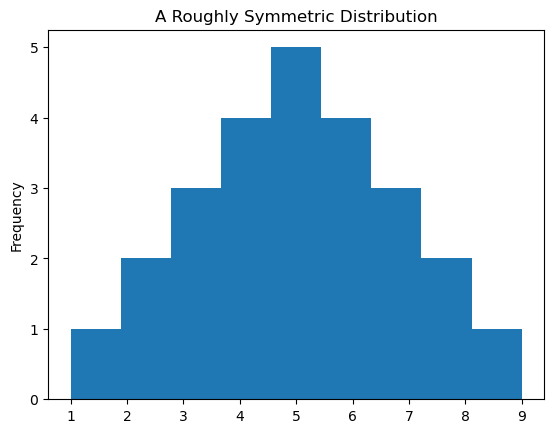

In [12]:
symmetric_values = pd.Series([
    1, 2, 2, 3, 3, 3, 4, 4, 4, 4,
    5, 5, 5, 5, 5, 6, 6, 6, 6, 7,
    7, 7, 8, 8, 9
])
symmetric_values.plot(
    kind="hist",
    bins=9,
    title="A Roughly Symmetric Distribution"
)


<Axes: title={'center': 'A Right-Skewed Distribution'}, ylabel='Frequency'>

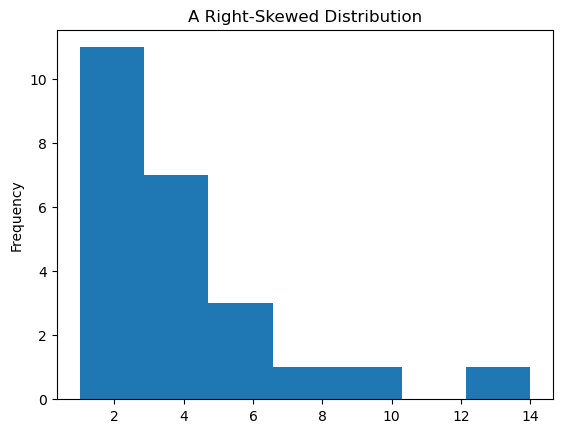

In [13]:
right_skewed_values = pd.Series([
    1, 1, 1, 1, 1, 2, 2, 2, 2, 2,
    2, 3, 3, 3, 3, 4, 4, 4, 5, 5,
    6, 8, 10, 14
])
right_skewed_values.plot(
    kind="hist",
    bins=7,
    title="A Right-Skewed Distribution"
)


<Axes: title={'center': 'A Left-Skewed Distribution'}, ylabel='Frequency'>

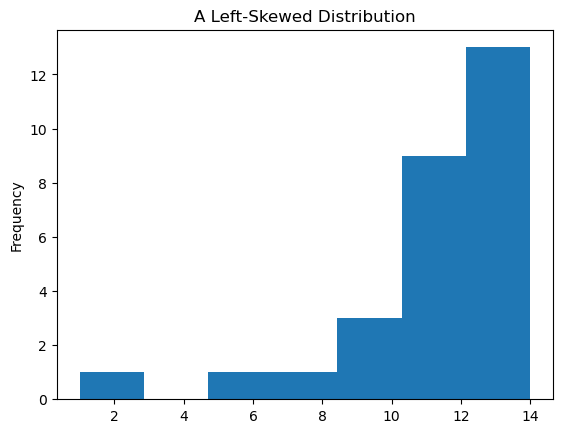

In [14]:
left_skewed_values = pd.Series([
    1, 5, 7, 9, 10, 10, 11, 11, 11, 11,
    12, 12, 12, 12, 12, 13, 13, 13, 13, 13,
    13, 14, 14, 14, 14, 14, 14, 14
])
left_skewed_values.plot(
    kind="hist",
    bins=7,
    title="A Left-Skewed Distribution"
)


<Axes: title={'center': 'A Distribution with Multiple Groups'}, ylabel='Frequency'>

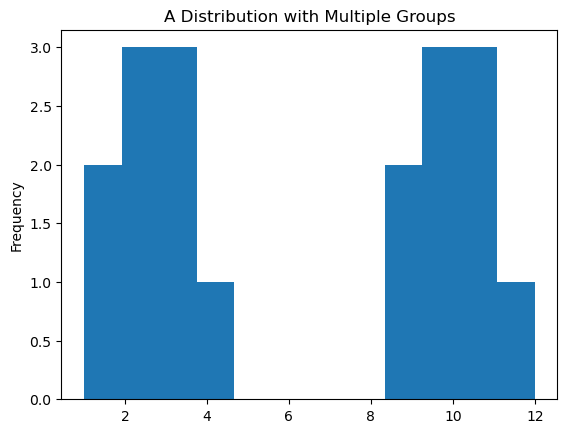

In [15]:
multiple_groups_values = pd.Series([
    1, 1, 2, 2, 2, 3, 3, 3, 4,
    9, 9, 10, 10, 10, 11, 11, 11, 12
])
multiple_groups_values.plot(
    kind="hist",
    bins=12,
    title="A Distribution with Multiple Groups"
)


In the symmetric example, the values taper away from the center in a similar way on both sides. In the right-skewed example, most observations are among the smaller values, while a few larger values form a long tail to the right. The left-skewed example reverses that pattern: most observations are among the larger values, while a few smaller values form a tail to the left.

The final histogram has two visible clusters separated by a gap. Multiple groups may suggest that different kinds of observations have been combined. A chart can help us notice the groups, but it does not by itself explain what caused them. Histogram bins can make all of these shapes easier or harder to recognize.


## How much do penguins typically weigh?

Body mass is quantitative, and the question asks about typical values and variation. A histogram will show which body-mass intervals occur most frequently, the approximate span of the observations, and the distribution's overall shape.

A single DataFrame column is a **Series**. `penguins["body_mass_g"]` selects the body-mass Series, and `.plot(kind="hist")` creates its histogram using the default bins.

Pandas can create a quick histogram before we import any additional plotting tools.


<Axes: ylabel='Frequency'>

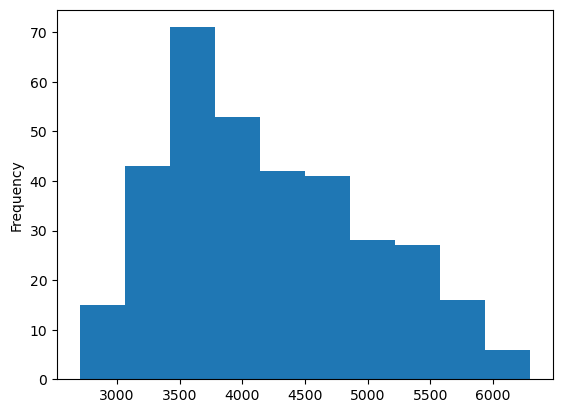

In [17]:
penguins_df["body_mass_g"].plot(kind='hist')

### Discussion: interpreting the unlabeled histogram

Use the histogram to discuss:

1. What appears to be a typical value or interval?
2. What is the approximate range from the least to the greatest value?
3. Does the distribution appear skewed or show more than one group?
4. Why is this difficult to understand without a title and axis labels?
5. Without the data dictionary, would we know what was being weighed or what `g` means?


A useful chart should have a descriptive title and axis labels. Labels should include units when units are available.

Matplotlib is a Python library for creating and customizing visualizations. We import its `pyplot` component using the conventional alias `plt` when we are ready to use its graphing capabilities.

Pandas makes it convenient to select a feature and quickly create a figure directly from a Series or DataFrame. Matplotlib gives us more control over the finished graph, so we use it to add a descriptive title, axis labels, units, and other annotations.

We can also change the appearance of the figure by adding arguments to `.plot()`. The argument `color="purple"` changes the color of all the histogram bars to purple.


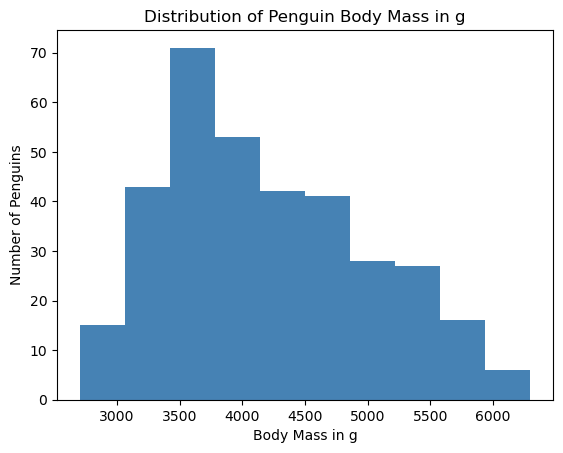

In [21]:
import matplotlib.pyplot as plt

penguins_df["body_mass_g"].plot(kind='hist', color='steelblue')
plt.title('Distribution of Penguin Body Mass in g')
plt.ylabel('Number of Penguins')
plt.xlabel('Body Mass in g')
plt.show()


The `color` argument changes the bar color. `plt.title()` describes the figure, while `plt.xlabel()` and `plt.ylabel()` describe the axes. `plt.show()` displays the completed figure.


These are estimates based on visual inspection. We can calculate more accurate values using Pandas.


## Describe a quantitative feature

The `.describe()` method provides numerical summaries for a quantitative feature. For now, focus on the mean, median, minimum, and maximum. The range is the maximum minus the minimum.

`.describe()` skips missing numeric values automatically, so its `count` reports the number of recorded body-mass measurements.


In [23]:
penguins_df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [24]:
penguins_df.mode()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Biscoe,41.1,17.0,190.0,3800.0,MALE


### Discussion: compare the estimates and calculations

1. How closely do the calculated mean, median, mode, minimum, maximum, and range match what we estimated from the histogram?
2. Why might the histogram make some values easier to estimate than others?


## Visualizing categorical features

A categorical distribution describes the categories that occur and their **frequency**, or how many observations belong to each category.

- A **bar chart** represents each category with a separate bar. Bar length or height shows frequency, making categories easy to compare.
- A **pie chart** represents categories as parts of one whole. It can work when there are only a few categories and the question emphasizes their shares of the total.


## Which penguin species is most common in our dataset?

Calling `.plot(kind="bar")` directly on the `species` column would not work because that Series contains text labels rather than bar heights. We first use `.value_counts()` to convert the labels into numerical frequencies. We can then plot those counts.


In [28]:
penguins_df['species'].value_counts()

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

<Axes: xlabel='species'>

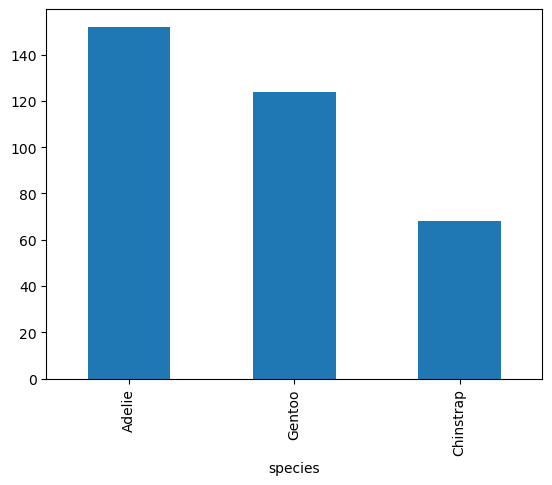

In [29]:
penguins_df['species'].value_counts().plot(kind='bar')

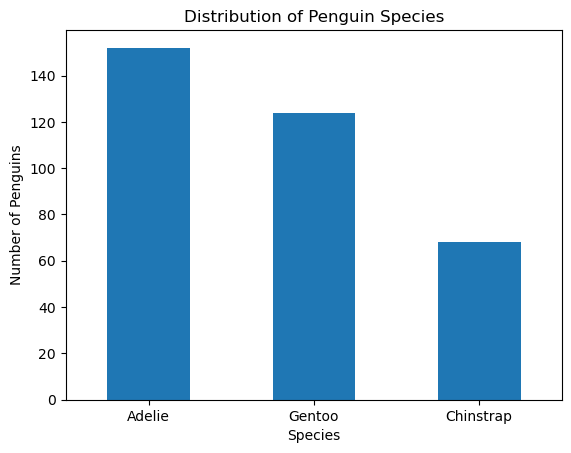

In [32]:
penguins_df['species'].value_counts().plot(kind='bar')
plt.title('Distribution of Penguin Species')
plt.ylabel('Number of Penguins')
plt.xticks(rotation=0)
plt.xlabel('Species')
plt.show()

### Discussion

1. Which species is most common in this dataset?
2. What visual evidence supports your answer?
3. How do the title and axis labels help you interpret the figure?


## What share of the penguin observations came from each of the three islands?

A pie chart can be appropriate when a small number of categories represent **parts of one whole**. The complete circle represents all observations, and each slice represents one category's share of that total.

The penguins were observed on only three islands, so an island pie chart remains readable. The percentages should add to 100% because every observation belongs to one island.


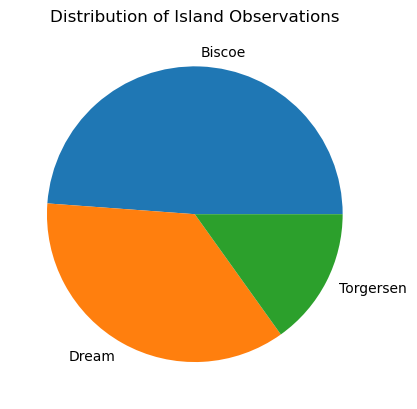

In [35]:
penguins_df['island'].value_counts().plot(kind='pie')
plt.title('Distribution of Island Observations')
plt.ylabel('')
plt.show()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


### Discussion

1. Which island accounts for the largest share of penguin observations?
2. Approximately what percentage of observations came from each island?
3. What does the complete circle represent?


Pie charts become difficult to read when there are many categories or when several slices are similar in size. A bar chart is usually better when the main goal is to compare category values precisely.


## Is the sample representative?

A **sample** is the set of observations included in a dataset. A **population** is the larger group we want to understand. A sample is **representative** when it resembles that larger population in the ways that matter for our question.

A large sample is not automatically representative. How the observations were selected matters. Before drawing a broader conclusion, ask:

- What population are we trying to understand?
- How were the observations selected?
- Which locations, groups, or time periods were included or left out?
- Are some groups represented much more often than others?
- Are important values missing?

### Discussion: interpreting the two categorical figures

1. Does the species bar chart establish which species is most common in the wild?
2. Does the island pie chart show the most common penguin habitats in Antarctica?
3. Would the conclusions from our pie chart remain the same if researchers observed penguins from land on one island and from a ship near another island?
4. Why might those different observation methods change the recorded frequencies?


## Discussion: choosing a chart

For each Palmer Penguins question, decide whether a histogram, bar chart, or pie chart would be a useful first visualization. Explain your choice.

1. What is the distribution of penguin flipper lengths?
2. What share of the observations belongs to each penguin species?
3. Are there more male or female penguins in our dataset?
4. What is the distribution of penguin bill lengths?


## Six principles for useful visualizations

1. **Clarity:** remove elements that do not support the message.
2. **Consistency:** use comparable scales, labels, and category meanings.
3. **Simplicity:** avoid unnecessary colors, decoration, and complexity.
4. **Accessibility:** use readable text, sufficient contrast, and more than color alone.
5. **Labeling and annotation:** provide descriptive titles, units, and useful context.
6. **Integrity:** avoid misleading scales and explain important transformations.


## Applying the principles: histogram bins

Changing the number of histogram bins changes how much detail we see:

- too few bins can hide important variation;
- too many bins can make small fluctuations look important; and
- trying more than one reasonable value helps us check whether the overall pattern is stable.

First, rerun the labeled body-mass histogram using the default number of bins. Use it as the baseline for the comparisons that follow.


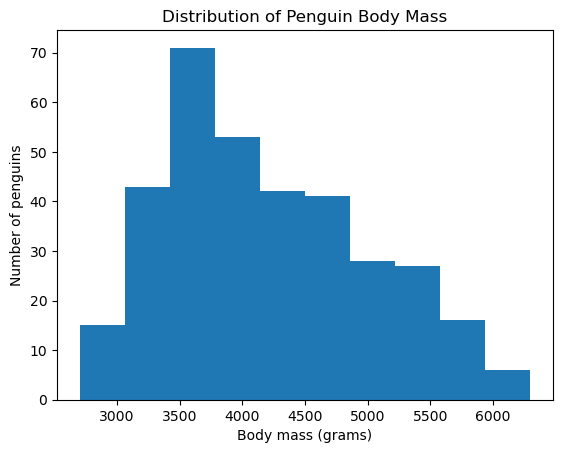

In [37]:
penguins_df["body_mass_g"].plot(kind="hist")
plt.title("Distribution of Penguin Body Mass")
plt.xlabel("Body mass (grams)")
plt.ylabel("Number of penguins")
plt.show()


Change the histogram to use 3 bins, then run it again using 30 bins. Keep the title and axis labels so all three versions can be compared clearly.


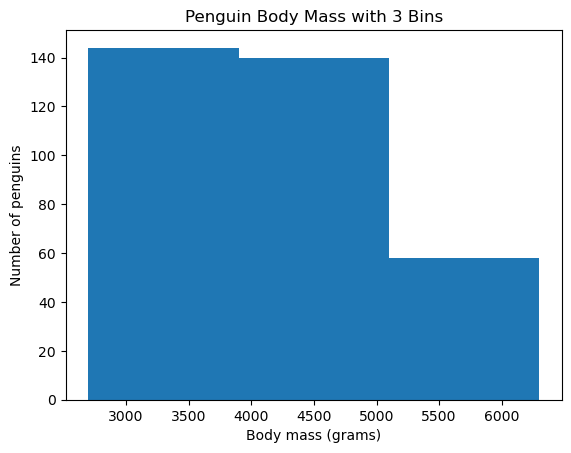

In [38]:
penguins_df["body_mass_g"].plot(kind="hist", bins=3)
plt.title("Penguin Body Mass with 3 Bins")
plt.xlabel("Body mass (grams)")
plt.ylabel("Number of penguins")
plt.show()


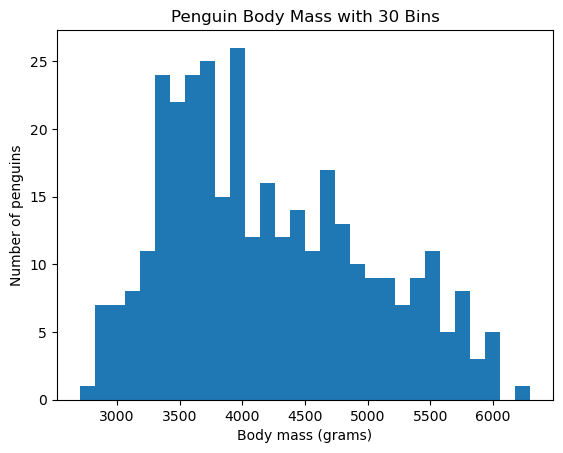

In [39]:
penguins_df["body_mass_g"].plot(kind="hist", bins=30)
plt.title("Penguin Body Mass with 30 Bins")
plt.xlabel("Body mass (grams)")
plt.ylabel("Number of penguins")
plt.show()


### Discussion

1. What did you observe when you changed the histogram from the default bins to 3 bins?
2. What did you observe when you changed it to 30 bins?
3. Which features of the distribution remained stable across all three figures?
4. Which features became easier or harder to see?
5. Did changing the bins change any underlying body-mass values?


## Applying the principles: a misleading vertical axis


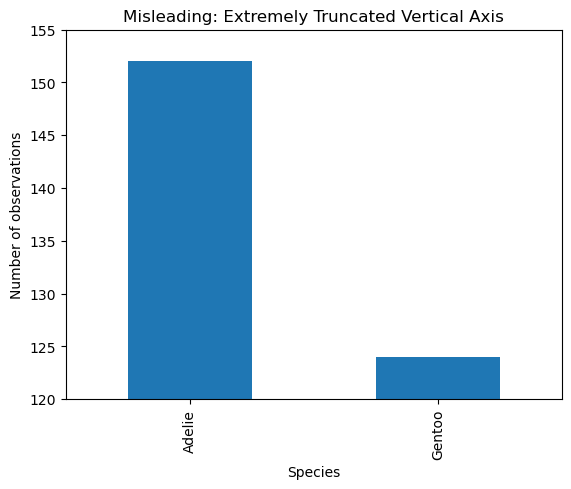

In [41]:
top_two_species = (
    penguins_df["species"]
    .value_counts()
    .sort_values(ascending=False)
    .head(2)
)

top_two_species.plot(kind="bar")
plt.ylim(120, 155)
plt.title("Misleading: Extremely Truncated Vertical Axis")
plt.xlabel("Species")
plt.ylabel("Number of observations")
plt.show()


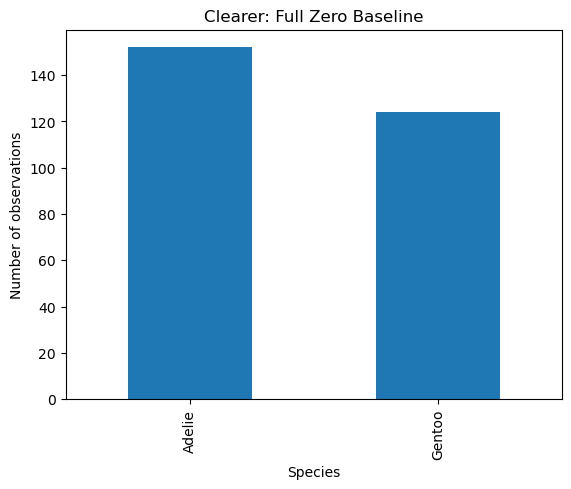

In [42]:
top_two_species.plot(kind="bar")
plt.title("Clearer: Full Zero Baseline")
plt.xlabel("Species")
plt.ylabel("Number of observations")
plt.show()


### Discussion

1. Which chart makes the difference between the species appear larger?
2. Did the underlying counts change between the two charts?
3. What changed about the vertical axis?
4. Which chart provides the more honest visual comparison, and why?


## Discussion: review

1. Why might the most common penguin species in this dataset differ from the most common penguin species in Antarctica?
2. What does a histogram reveal that `.describe()` does not?
3. What does `.describe()` reveal more precisely than a histogram?
4. How can changing a histogram's bins or a bar chart's axis limits change the impression created by a figure?
5. What limitation should accompany a claim based only on the observed Palmer Penguins sample?


## Summary

In this lecture, we inspected a DataFrame, classified features, and visualized quantitative and categorical distributions. We also distinguished sample evidence from population claims and examined how labels, histogram bins, and axis limits affect interpretation. The next lecture will use Pandas to make this analysis more efficient and reproducible.
